<a href="https://colab.research.google.com/github/Maryam-Skaik/test/blob/main/notebook/NYC_Taxi_Trip_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Taxi Trip Analysis
# Unsupervised Machine Learning Project


### Goal

The goal of this project is to explore real-world transportation behavior in New York City using unsupervised machine learning techniques.

We will work on the NYC Yellow Taxi Trip dataset to:

- Discover hidden trip behavior patterns using KMeans clustering
- Evaluate clustering quality using Inertia and Silhouette Score
- Explain and interpret clusters through aggregated feature analysis
- Detect anomalous and suspicious trips using KMeans distance analysis and Isolation Forest
- Analyze temporal, spatial, and financial taxi trip behavior

This project simulates a real-world mobility analytics and anomaly detection workflow using large-scale transportation data.

## Import Libraries

In [50]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [51]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/Practice/Data/yellow_tripdata_2024-02.parquet'
df = pd.read_parquet(fpath)
df = df.sample(200000, random_state=42)

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1383855,2,2024-02-15 11:11:19,2024-02-15 11:15:33,1.0,0.74,1.0,N,234,186,1,5.8,0.0,0.5,2.94,0.0,1.0,12.74,2.5,0.0
1610201,2,2024-02-17 15:02:44,2024-02-17 15:20:49,1.0,2.36,1.0,N,164,50,1,18.4,0.0,0.5,4.48,0.0,1.0,26.88,2.5,0.0
1712151,1,2024-02-18 16:05:09,2024-02-18 16:10:30,1.0,0.70,1.0,N,162,229,1,6.5,2.5,0.5,2.10,0.0,1.0,12.60,2.5,0.0
317699,1,2024-02-04 00:48:15,2024-02-04 01:08:19,2.0,4.20,1.0,N,114,143,1,22.6,3.5,0.5,3.00,0.0,1.0,30.60,2.5,0.0
1713803,2,2024-02-18 16:40:48,2024-02-18 16:47:37,2.0,0.93,1.0,N,161,142,1,8.6,0.0,0.5,1.00,0.0,1.0,13.60,2.5,0.0


* Data represents taxi trip records with pickup and dropoff timestamps
* Each row is a single trip with fare breakdown and trip metadata
* Most trips shown involve 1–2 passengers
* Trip distances are generally short (under ~5 miles in the sample)
* store_and_fwd_flag is mostly “N”, meaning data is transmitted in real time
* fare_amount plus extras (tax, surcharges, tips) combine into total_amount
* tip_amount varies depending on trip and likely payment method
* congestion_surcharge and Airport_fee are mostly zero or fixed values in this sample
* VendorID suggests multiple taxi providers contributing to the dataset

## Dataset Overview

In [52]:
df.shape

(200000, 19)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1383855 to 1690810
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               200000 non-null  int32         
 1   tpep_pickup_datetime   200000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  200000 non-null  datetime64[us]
 3   passenger_count        187785 non-null  float64       
 4   trip_distance          200000 non-null  float64       
 5   RatecodeID             187785 non-null  float64       
 6   store_and_fwd_flag     187785 non-null  object        
 7   PULocationID           200000 non-null  int32         
 8   DOLocationID           200000 non-null  int32         
 9   payment_type           200000 non-null  int64         
 10  fare_amount            200000 non-null  float64       
 11  extra                  200000 non-null  float64       
 12  mta_tax                200000 non-null  fl

* Dataset contains 200,000 taxi trip records with 19 features
* Two datetime columns: pickup and dropoff timestamps for trip duration analysis
* Numerical dominance: most features are float or integer types, suitable for modeling
* 3 categorical-like numeric IDs: VendorID, PULocationID, DOLocationID
* payment_type is integer-encoded categorical variable
* store_and_fwd_flag is the only object (string) column
* Missing values exist in 5 columns: `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`
* Missingness is identical across those columns (187,785 vs 200,000) suggesting linked data availability issue
* passenger_count and RatecodeID are partially missing (~6% missing)
* surcharge-related fields (congestion_surcharge, Airport_fee) also partially missing
* Data is well-structured and mostly complete, with no missing values in core transactional fields (fare_amount, trip_distance, total_amount)

In [54]:
df = df.drop(columns=['PULocationID', 'DOLocationID'])
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1383855,2,2024-02-15 11:11:19,2024-02-15 11:15:33,1.0,0.74,1.0,N,1,5.8,0.0,0.5,2.94,0.0,1.0,12.74,2.5,0.0
1610201,2,2024-02-17 15:02:44,2024-02-17 15:20:49,1.0,2.36,1.0,N,1,18.4,0.0,0.5,4.48,0.0,1.0,26.88,2.5,0.0
1712151,1,2024-02-18 16:05:09,2024-02-18 16:10:30,1.0,0.70,1.0,N,1,6.5,2.5,0.5,2.10,0.0,1.0,12.60,2.5,0.0
317699,1,2024-02-04 00:48:15,2024-02-04 01:08:19,2.0,4.20,1.0,N,1,22.6,3.5,0.5,3.00,0.0,1.0,30.60,2.5,0.0
1713803,2,2024-02-18 16:40:48,2024-02-18 16:47:37,2.0,0.93,1.0,N,1,8.6,0.0,0.5,1.00,0.0,1.0,13.60,2.5,0.0


In [55]:
df.describe(include='all').round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,200000.00,200000,200000,187785.00,200000.00,187785.00,187785,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,187785.00,187785.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,187098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.75,2024-02-15 19:01:57.823455,2024-02-15 19:17:55.488540,1.32,3.52,2.10,NaN,1.13,18.07,1.45,0.48,3.32,0.51,0.98,26.66,2.27,0.13
min,1.00,2024-01-31 23:58:03,2024-02-01 00:01:54,0.00,0.00,1.00,NaN,0.00,-499.00,-7.50,-0.50,-15.80,-33.80,-1.00,-359.58,-2.50,-1.75
25%,2.00,2024-02-08 14:22:34.500000,2024-02-08 14:41:47.750000,1.00,1.00,1.00,NaN,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.48,2.50,0.00
50%,2.00,2024-02-15 18:16:35.500000,2024-02-15 18:32:26,1.00,1.70,1.00,NaN,1.00,12.80,1.00,0.50,2.72,0.00,1.00,20.16,2.50,0.00
75%,2.00,2024-02-23 08:19:14.250000,2024-02-23 08:35:03,1.00,3.10,1.00,NaN,1.00,20.50,2.50,0.50,4.14,0.00,1.00,28.60,2.50,0.00
max,2.00,2024-02-29 23:59:34,2024-03-01 15:48:25,8.00,63488.35,99.00,NaN,4.00,605.70,12.50,0.50,154.10,94.00,1.00,616.14,2.50,1.75


* Dataset spans a very consistent time window, with pickup and dropoff times centered around mid-February 2024
* Trip durations vary widely, from very short rides to long trips extending beyond normal daily ranges
* passenger_count is mostly concentrated around small groups, but can reach up to larger shared rides
* trip_distance shows extreme variability, including very long-distance outliers
* RatecodeID is heavily concentrated in a single dominant category, with rare alternative ride types
* payment_type is mostly dominated by one main category, with few occurrences of others
* fare_amount shows strong right-skew with occasional very high values and some negative anomalies
* extra and mta_tax are mostly stable but include rare negative or irregular entries
* tip_amount is highly variable, including zero tips and unusually large tipping cases
* tolls_amount and improvement_surcharge are mostly small but contain occasional extreme outliers
* total_amount reflects combined charges and inherits extreme negative and positive outliers from components
* congestion_surcharge is mostly fixed at a single value for most trips
* Airport_fee is almost always zero with very rare non-zero values
* store_and_fwd_flag is strongly dominated by a single category, with very few records in the other class
* Several numerical columns show evidence of outliers or invalid values (negative or extremely large), which may require cleaning before modeling

### Remove clearly invalid (negative) monetary values

In [56]:
clean_df = df[
    (df["fare_amount"] >= 0) &
    (df["tip_amount"] >= 0) &
    (df["total_amount"] >= 0) &
    (df["tolls_amount"] >= 0) &
    (df["extra"] >= 0) &
    (df["mta_tax"] >= 0) &
    (df["improvement_surcharge"] >= 0) &
    (df["congestion_surcharge"] >= 0) &
    (df["Airport_fee"] >= 0)
].copy()

# sanity check
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)
print("Removed rows:", df.shape[0] - clean_df.shape[0])

Original shape: (200000, 17)
Cleaned shape: (185401, 17)
Removed rows: 14599


In [57]:
clean_df.describe(include='all').round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,185401.00,185401,185401,185401.00,185401.00,185401.00,185401,185401.00,185401.00,185401.00,185401.00,185401.00,185401.00,185401.00,185401.00,185401.00,185401.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,184714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.76,2024-02-15 15:43:21.930254,2024-02-15 15:59:20.642229,1.32,3.23,2.11,NaN,1.18,18.52,1.57,0.50,3.50,0.54,1.00,27.50,2.32,0.13
min,1.00,2024-01-31 23:58:03,2024-02-01 00:04:23,0.00,0.00,1.00,NaN,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,2024-02-08 11:21:10,2024-02-08 11:38:25,1.00,1.00,1.00,NaN,1.00,8.60,0.00,0.50,1.10,0.00,1.00,15.60,2.50,0.00
50%,2.00,2024-02-15 15:25:18,2024-02-15 15:48:22,1.00,1.68,1.00,NaN,1.00,12.80,1.00,0.50,2.86,0.00,1.00,20.30,2.50,0.00
75%,2.00,2024-02-22 22:38:16,2024-02-22 22:53:40,1.00,3.07,1.00,NaN,1.00,20.50,2.50,0.50,4.28,0.00,1.00,28.92,2.50,0.00
max,2.00,2024-02-29 23:59:34,2024-03-01 15:48:25,8.00,9900.60,99.00,NaN,4.00,605.70,12.50,0.50,140.00,94.00,1.00,616.14,2.50,1.75


* Removed 14,599 records (~7.3% of the dataset) containing invalid negative financial values
* Ensured all monetary-related fields are now strictly non-negative
* Dataset size reduced from 200,000 to 185,401 rows while keeping full feature structure
* Trip distance still shows high variability with extreme long-distance values preserved for anomaly detection
* Fare and total amount distributions remain strongly right-skewed but now clean from impossible negative values
* Passenger counts and categorical structure remain unchanged and consistent after cleaning
* RatecodeID and payment_type distributions remain stable, indicating no structural data loss
* store_and_fwd_flag still heavily dominated by a single category
* Maximum values remain very high in several features, confirming that extreme but potentially valid trips were retained
* Overall dataset is now logically consistent and suitable for KMeans clustering and anomaly detection workflow

In [58]:
clean_df.isnull().sum().sum()

np.int64(0)

### Convert Datetime Columns

In [59]:
clean_df['tpep_pickup_datetime'] = pd.to_datetime(clean_df['tpep_pickup_datetime'])
clean_df['tpep_dropoff_datetime'] = pd.to_datetime(clean_df['tpep_dropoff_datetime'])

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185401 entries, 1383855 to 1690810
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               185401 non-null  int32         
 1   tpep_pickup_datetime   185401 non-null  datetime64[us]
 2   tpep_dropoff_datetime  185401 non-null  datetime64[us]
 3   passenger_count        185401 non-null  float64       
 4   trip_distance          185401 non-null  float64       
 5   RatecodeID             185401 non-null  float64       
 6   store_and_fwd_flag     185401 non-null  object        
 7   payment_type           185401 non-null  int64         
 8   fare_amount            185401 non-null  float64       
 9   extra                  185401 non-null  float64       
 10  mta_tax                185401 non-null  float64       
 11  tip_amount             185401 non-null  float64       
 12  tolls_amount           185401 non-null  fl

### Create Trip Duration Feature

In [60]:
clean_df['trip_duration_min'] = ((clean_df['tpep_dropoff_datetime'] - clean_df['tpep_pickup_datetime']).dt.total_seconds() / 60).round(2)
clean_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_min
1383855,2,2024-02-15 11:11:19,2024-02-15 11:15:33,1.0,0.74,1.0,N,1,5.8,0.0,0.5,2.94,0.0,1.0,12.74,2.5,0.0,4.23
1610201,2,2024-02-17 15:02:44,2024-02-17 15:20:49,1.0,2.36,1.0,N,1,18.4,0.0,0.5,4.48,0.0,1.0,26.88,2.5,0.0,18.08
1712151,1,2024-02-18 16:05:09,2024-02-18 16:10:30,1.0,0.70,1.0,N,1,6.5,2.5,0.5,2.10,0.0,1.0,12.60,2.5,0.0,5.35
317699,1,2024-02-04 00:48:15,2024-02-04 01:08:19,2.0,4.20,1.0,N,1,22.6,3.5,0.5,3.00,0.0,1.0,30.60,2.5,0.0,20.07
1713803,2,2024-02-18 16:40:48,2024-02-18 16:47:37,2.0,0.93,1.0,N,1,8.6,0.0,0.5,1.00,0.0,1.0,13.60,2.5,0.0,6.82


* Converted pickup and dropoff columns into proper datetime format for time-based analysis
* Ensured both datetime columns are consistent and correctly typed as datetime64[us]
* Created a new feature `trip_duration_min` representing trip duration in minutes
* Trip duration is computed as the difference between dropoff and pickup timestamps
* New feature reveals realistic trip durations, from very short rides to longer urban trips
* Dataset now supports temporal feature engineering for clustering and anomaly detection tasks
* Time-based behavior can now be analyzed alongside distance and fare patterns for richer clustering features

## Feature Engineering

### Temporal Features

In [61]:
clean_df['pickup_hour'] = clean_df['tpep_pickup_datetime'].dt.hour
clean_df['pickup_day'] = clean_df['tpep_pickup_datetime'].dt.dayofweek
clean_df['is_weekend'] = clean_df['pickup_day'].isin([5, 6]).astype(int)

### Financial Features

In [62]:
clean_df['tip_ratio'] = (
    clean_df['tip_amount'] /
    clean_df['fare_amount'].replace(0, np.nan)
)

clean_df['tip_ratio'] = clean_df['tip_ratio'].fillna(0)

In [63]:
clean_df['fare_per_mile'] = (
    clean_df['fare_amount'] /
    clean_df['trip_distance'].replace(0, np.nan)
)

### Average Speed

In [64]:
clean_df['avg_speed_mph'] = (
    clean_df['trip_distance'] /
    (clean_df['trip_duration_min'] / 60)
)

clean_df = clean_df[
    (clean_df['avg_speed_mph'] > 0) &
    (clean_df['avg_speed_mph'] < 120)
]

* Extracted temporal features from pickup timestamps to capture travel behavior patterns over time
* Created `pickup_hour` to distinguish trips across different times of the day
* Created `pickup_day` to represent weekday patterns numerically
* Added `is_weekend` feature to separate weekday and weekend trip behavior
* Engineered financial ratio features to better describe ride efficiency and customer behavior
* Created `tip_ratio` to measure tipping behavior relative to fare amount
* Created `fare_per_mile` to analyze ride cost efficiency and detect unusual pricing patterns
* Added `avg_speed_mph` feature using trip distance and trip duration
* Average speed helps identify traffic conditions, abnormal trips, and unrealistic ride behavior
* Feature engineering transformed raw transactional data into behavior-focused features more suitable for KMeans clustering and anomaly detection

## Select Features for Clustering

In [65]:
features = [
    'trip_distance',
    'trip_duration_min',
    'avg_speed_mph',
    'fare_amount',
    'tip_amount',
    'tip_ratio',
    'fare_per_mile',
    'pickup_hour',
    'passenger_count'
]

X = clean_df[features]
X.head()

,trip_distance,trip_duration_min,avg_speed_mph,fare_amount,tip_amount,tip_ratio,fare_per_mile,pickup_hour,passenger_count
1383855,0.74,4.23,10.496454,5.8,2.94,0.506897,7.837838,11,1.0
1610201,2.36,18.08,7.831858,18.4,4.48,0.243478,7.796610,15,1.0
1712151,0.70,5.35,7.850467,6.5,2.10,0.323077,9.285714,16,1.0
317699,4.20,20.07,12.556054,22.6,3.00,0.132743,5.380952,0,2.0
1713803,0.93,6.82,8.181818,8.6,1.00,0.116279,9.247312,16,2.0


## Feature Scaling

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method

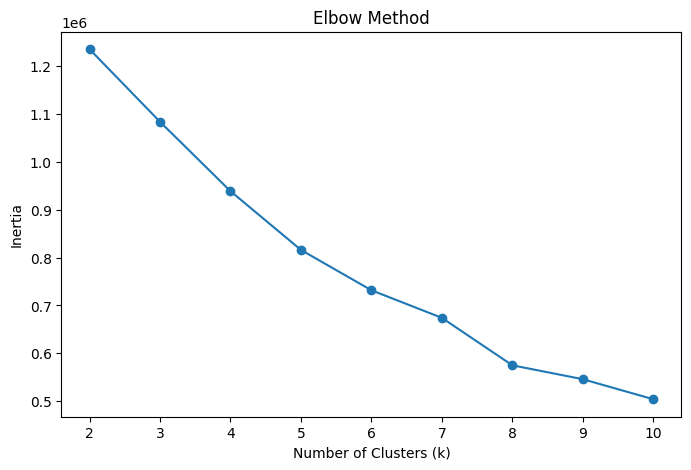

In [68]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show();

## Silhouette Score Evaluation

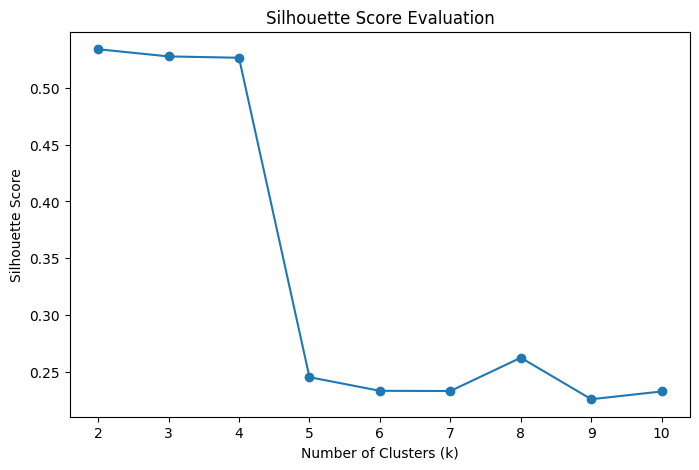

In [69]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)
plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Evaluation')

plt.show();

## Train Final KMeans Model

In [70]:
kmeans = KMeans(n_clusters=4, random_state=42)
clean_df['cluster'] = kmeans.fit_predict(X_scaled)

## Cluster Distribution

In [71]:
clean_df['cluster'].value_counts()

,count
cluster,
0,162414
1,20589
2,96
3,49


## Cluster Profiling

In [72]:
cluster_profile = clean_df.groupby('cluster')[features].mean().round(2)
cluster_profile

,trip_distance,trip_duration_min,avg_speed_mph,fare_amount,tip_amount,tip_ratio,fare_per_mile,pickup_hour,passenger_count
cluster,,,,,,,,,
0,1.93,12.64,9.52,13.58,2.70,0.22,9.55,14.39,1.32
1,13.38,36.88,23.79,56.10,9.87,0.19,9.11,14.43,1.39
2,3.65,1376.03,0.18,19.21,1.58,0.10,8.14,13.49,2.06
3,0.01,0.18,5.63,76.38,6.62,0.08,7294.81,14.67,1.45


## Visualizing Cluster Means

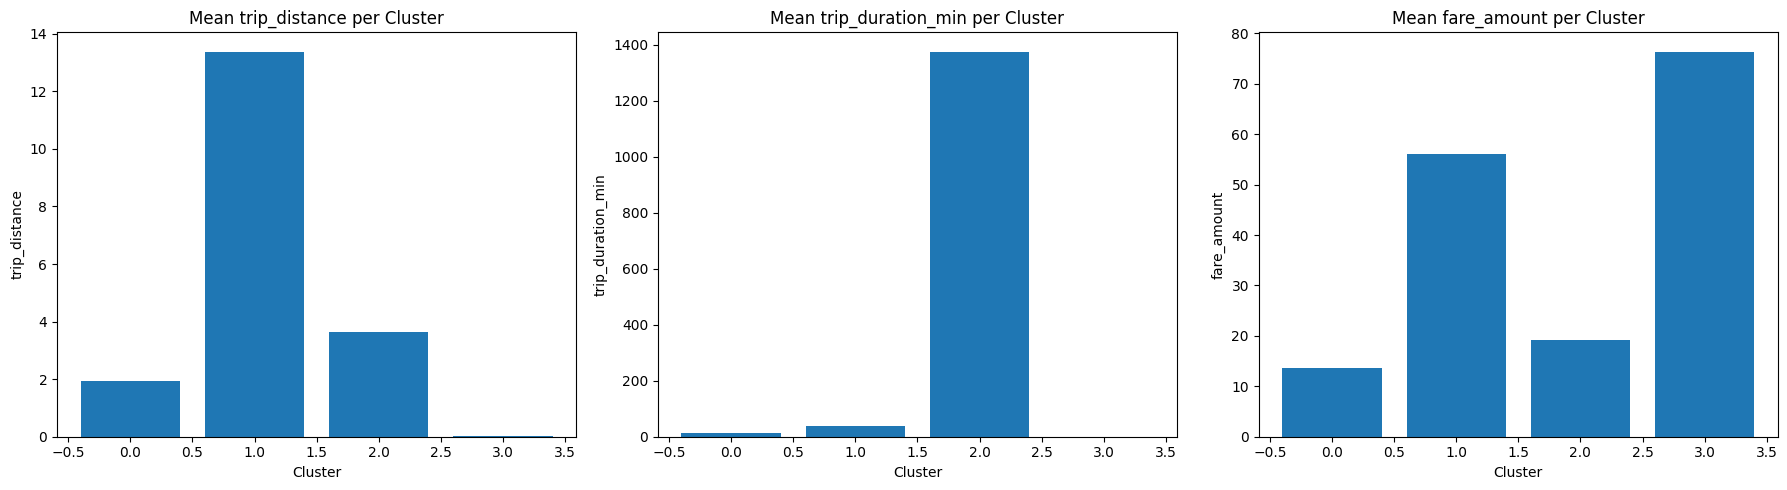

In [76]:
cluster_groups = clean_df.groupby('cluster')[features].mean()

viz_features = ['trip_distance', 'trip_duration_min', 'fare_amount']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(viz_features):
    axes[i].bar(cluster_groups.index, cluster_groups[col])
    axes[i].set_title(f'Mean {col} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show();

* The dataset was segmented into 4 distinct customer/trip behavior clusters using KMeans
* Each cluster represents a different type of taxi trip pattern based on distance, duration, fare, speed, and tipping behavior
* Cluster sizes are highly imbalanced, showing that most trips belong to normal behavior patterns while a few represent rare or extreme cases
* Clusters can be interpreted as different “trip personas” that help understand revenue sources and anomalies

---

### Cluster 0 (Standard Urban Trips)

* Is the dominant group, representing the majority of rides with short distances and normal durations
* These trips have moderate fares, low variability, and typical urban travel behavior
* This cluster represents the core business volume and stable daily income
* Recommendation: optimize pricing stability and improve service quality here since it drives most revenue

---

### Cluster 1 (Long Distance / High Value Trips)

* Contains fewer but significantly longer trips with higher fares and longer durations
* These rides generate much higher revenue per trip compared to standard trips
* They often represent inter-city or airport-like travel patterns
* Recommendation: focus on retention and premium service (priority rides, dynamic pricing, promotions for long trips) to maximize revenue from this segment

---

### Cluster 2 (Slow / Traffic-Heavy Trips)

* Represents trips with very long duration but relatively low speed
* These rides are likely affected by heavy traffic or inefficiencies in routing
* They do not generate high revenue despite long time usage of drivers
* Recommendation: optimize routing, introduce surge pricing in high-traffic zones, or analyze congestion patterns for operational improvement

---

### Cluster 3 (Anomalous / Irregular Trips)

* Is a very small group with extreme or unusual feature values
* Includes abnormal fare-per-mile ratios and inconsistent trip patterns
* This cluster likely contains data anomalies, special cases, or pricing inconsistencies
* Recommendation: investigate these records for fraud detection, data errors, or special pricing rules

---

* Overall, the clustering reveals four clear behavior groups ranging from normal mass usage to high-value trips and anomaly cases
* These insights can be used to improve pricing strategy, detect anomalies, and target high-revenue customer segments more effectively


## KMeans-Based Anomaly Detection

In [77]:
distances = kmeans.transform(X_scaled)

# Take minimum distance (closest cluster center)
clean_df['distance_to_center'] = np.min(distances, axis=1)

In [78]:
# Define anomaly threshold (top 1% farthest points)
threshold = clean_df['distance_to_center'].quantile(0.99)

# Flag anomalies
clean_df['kmeans_anomaly'] = (
    clean_df['distance_to_center'] > threshold
).astype(int)

In [82]:
(clean_df['kmeans_anomaly'] == 1).sum()

np.int64(1832)

In [80]:
idx_anomalies = clean_df[clean_df['kmeans_anomaly'] == 1].index

### Visualize KMeans Anomalies

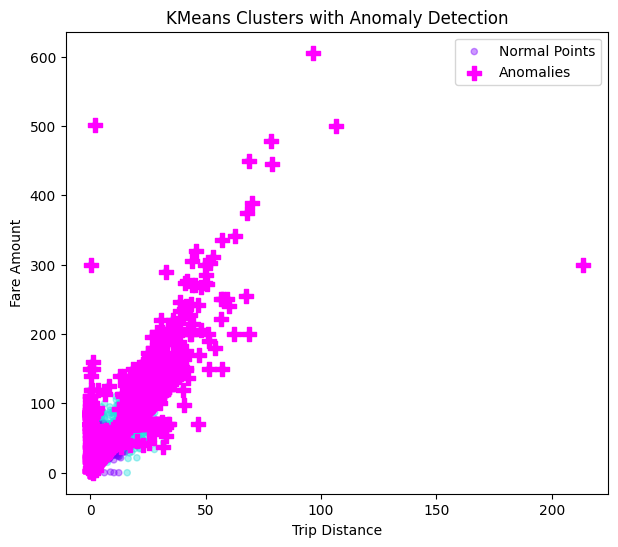

In [81]:
fig, ax = plt.subplots(figsize=(7, 6))

# Normal points (colored by cluster)
ax.scatter(
    clean_df["trip_distance"],
    clean_df["fare_amount"],
    c=clean_df["cluster"],
    cmap="rainbow",
    alpha=0.4,
    s=20,
    label="Normal Points"
)

# Anomalies highlighted
clean_df.loc[idx_anomalies].plot(
    x="trip_distance",
    y="fare_amount",
    kind="scatter",
    color="magenta",
    label="Anomalies",
    ax=ax,
    marker="P",
    s=100
)

ax.set_xlabel("Trip Distance")
ax.set_ylabel("Fare Amount")
ax.set_title("KMeans Clusters with Anomaly Detection")

plt.legend()
plt.show();

* KMeans-based anomaly detection was performed using distance from each point to its nearest cluster center
* An anomaly threshold was defined using the 99th percentile of the distance distribution
* A total of 1,832 records were flagged as anomalous cases in the dataset
* These anomalies represent approximately 1% of the dataset, focusing on extreme or unusual trip behavior

---

* The visualization combines normal clustered trips and detected anomalies in a single scatter plot
* Normal trips show a clear pattern where higher trip distance generally corresponds to higher fare amount
* Clusters are visible in the background, representing different behavioral groups learned by KMeans
* Most trips are concentrated in short-distance, low-fare regions, forming a dense main cluster

---

* Anomalies are highlighted in magenta and represent points that are far from any learned cluster center
* These include unusual cases such as very high fares for very short trips and inconsistent fare-distance relationships
* Some anomalies also appear in long-distance regions where pricing does not follow the general trend

---

* The strong overlap of anomaly points over the main cluster is expected because KMeans uses high-dimensional distance (multiple features), while the plot shows only 2 features
* This means some points look normal in 2D space but are still anomalous in full feature space
* The visualization compresses multi-feature behavior into a 2D projection, causing visual stacking and overlap

---

* Overall, the anomaly detection successfully highlights rare and unusual trip behaviors that deviate from normal taxi patterns
* These cases can represent data errors, pricing inconsistencies, or rare high-value operational scenarios
* The model is useful for identifying edge cases for further investigation in pricing, fraud detection, or operational optimization

## Isolation Forest Anomaly Detection

In [83]:
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

# Fit model and predict anomalies
clean_df['isolation_anomaly'] = iso.fit_predict(X_scaled)

In [84]:
# 1 -> normal, -1 -> anomaly
clean_df['isolation_anomaly'] = clean_df['isolation_anomaly'].map({
    1: 0,
    -1: 1
})

In [85]:
print(clean_df['isolation_anomaly'].value_counts())

isolation_anomaly
0    181316
1      1832
Name: count, dtype: int64


### Visualize Isolation Forest Anomalies

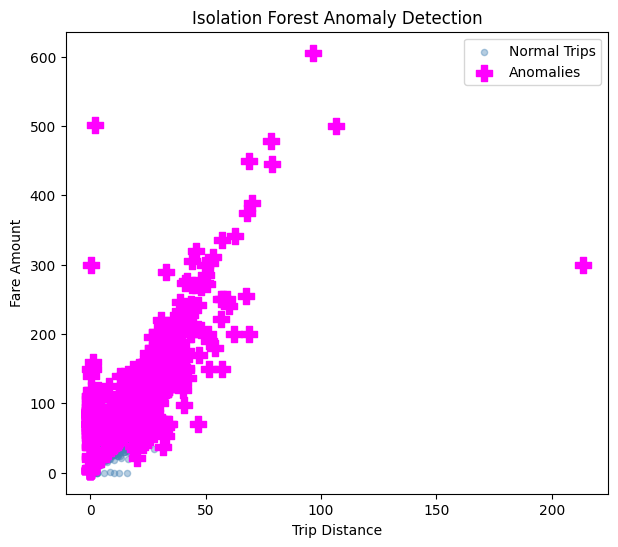

In [88]:
fig, ax = plt.subplots(figsize=(7, 6))

# Normal points
ax.scatter(
    clean_df['trip_distance'],
    clean_df['fare_amount'],
    c='steelblue',
    alpha=0.4,
    s=20,
    label='Normal Trips'
)

# Anomalies
clean_df[clean_df['isolation_anomaly'] == 1].plot(
    x='trip_distance',
    y='fare_amount',
    kind='scatter',
    ax=ax,
    color='magenta',
    marker='P',
    s=120,
    label='Anomalies'
)

ax.set_xlabel('Trip Distance')
ax.set_ylabel('Fare Amount')
ax.set_title('Isolation Forest Anomaly Detection')

plt.legend()
plt.show();

In [87]:
clean_df[clean_df['isolation_anomaly'] == 1][[
    'trip_distance',
    'fare_amount',
    'trip_duration_min',
    'tip_amount',
    'tip_ratio'
]].head()

,trip_distance,fare_amount,trip_duration_min,tip_amount,tip_ratio
1387958,23.09,84.9,35.35,12.96,0.152650
1539301,22.84,90.5,70.62,0.00,0.000000
834217,14.70,120.0,44.80,5.62,0.046833
2654212,16.68,80.7,70.92,21.80,0.270136
1819693,29.01,70.0,38.97,10.00,0.142857


* Isolation Forest was applied as a second anomaly detection method using the same scaled feature set
* The model was configured with a contamination rate of 1% to match the expected proportion of anomalies in the dataset
* The algorithm identifies anomalies by isolating observations that are easier to separate from the rest of the data
* Predictions were mapped to binary labels where 0 represents normal trips and 1 represents anomalies

---

* The model detected 1,832 anomalous trips in total
* This represents approximately 1% of the dataset, consistent with the expected contamination level

---

* The visualization shows normal trips in blue and anomalies highlighted in magenta
* Normal trips follow the expected pattern where higher trip distance generally leads to higher fare amount
* Most data points are concentrated in short-distance, low-fare regions forming a dense core structure
* Anomalies appear as scattered points away from the main distribution pattern

---

* Detected anomalies include long-distance trips with unusually high or inconsistent fare and tip behavior
* Some cases show high fares with relatively normal durations, indicating potential pricing irregularities
* Other cases reflect unusual combinations of distance, fare, and tipping behavior

---

* The anomaly samples show diverse patterns such as high fare with zero tip or unusually high tip ratios
* These cases are likely to represent rare trips, edge-case pricing, or potential data inconsistencies

---

* Overall, Isolation Forest confirms the anomaly patterns detected by KMeans while providing a different detection mechanism
* Both methods consistently identify around 1% of the dataset as unusual behavior
* Combining both approaches increases confidence in identifying true anomalies versus model-specific noise
* These results can be used for fraud detection, pricing validation, and operational analysis in taxi trip systems

## Intersection of Detected Anomalies

In [89]:
# Indices from KMeans anomalies
kmeans_anomalies_indices = clean_df[clean_df['kmeans_anomaly'] == 1].index

# Indices from Isolation Forest anomalies
iso_anomalies_indices = clean_df[clean_df['isolation_anomaly'] == 1].index

# Common anomalies detected by both methods
common_anomalies = set(kmeans_anomalies_indices).intersection(set(iso_anomalies_indices))

print("Number of anomalies detected by both methods:", len(common_anomalies))

Number of anomalies detected by both methods: 678


* Compared anomaly detection results from both KMeans-based and Isolation Forest methods
* Extracted the intersection of detected anomaly indices from both models
* Found 678 common anomalies identified by both approaches
* These overlapping cases represent high-confidence anomalies since they are flagged by two different detection techniques
* Using multiple models increases reliability by reducing model-specific noise and highlighting consistent outliers
* These shared anomalies are strong candidates for further investigation in fraud detection, pricing errors, or operational irregularities

## Key Insights

* Taxi trip behavior can be effectively grouped into meaningful clusters using unsupervised learning
* Most trips follow predictable patterns of short distance and low-to-moderate fare values
* A small portion of trips represent high-value or unusual behavior that differs significantly from the majority
* Temporal and financial behavior features significantly improve clustering quality
* Distance-based and model-based anomaly detection methods both successfully identify irregular trip patterns
* Combining multiple anomaly detection techniques increases reliability and confidence in detected outliers

---

## Examples of Insights

* Standard urban trips form the largest cluster and represent the core revenue stream
* Long-distance trips generate significantly higher fares and represent premium revenue opportunities
* Slow-speed trips are likely influenced by traffic congestion and operational inefficiencies
* Extremely small cluster groups capture rare or abnormal behavior patterns in the dataset
* Airport-related trips behave differently in terms of distance, fare, and pricing structure
* Anomalies often show inconsistent relationships between distance, fare, and tipping behavior
* Some detected outliers are shared across both models, indicating high-confidence anomalies

---

## Conclusion

In this project, unsupervised machine learning techniques were applied to real-world NYC taxi trip data to understand travel behavior and detect anomalies.

The workflow successfully included:

* Feature engineering of behavioral, temporal, and financial attributes
* Clustering taxi trips using KMeans
* Evaluating cluster quality and interpreting behavioral segments
* Detecting anomalies using both KMeans distance-based approach and Isolation Forest
* Comparing models and identifying high-confidence overlapping anomalies

This project demonstrates how unsupervised learning can be used to extract meaningful patterns from large-scale transportation data, improve operational understanding, and detect abnormal or suspicious trip behavior without labeled data.